## EDA
Performer Jay

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [35]:
# Load Original Dataset
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "credit_risk_dataset.csv"
df = pd.read_csv(DATA_PATH)

In [36]:
# Data Cleaning
df_clean = df.copy()

# Remove duplicate records
df_clean = df_clean.drop_duplicates()

# Remove invalid records
df_clean = df_clean[
    (df_clean["person_age"] < 100)
    & (df_clean["person_emp_length"] < 100)
]

# Convert loan grades into ordinal scores
grade_mapping = {
    "A": 7,
    "B": 6,
    "C": 5,
    "D": 4,
    "E": 3,
    "F": 2,
    "G": 1,
}

df_clean["loan_grade"] = df_clean["loan_grade"].map(grade_mapping)

# Fill missing values
numerical_columns = df_clean.select_dtypes(include="number").columns
categorical_columns = df_clean.select_dtypes(include="str").columns

df_clean[numerical_columns] = df_clean[numerical_columns].fillna(-1.0)
df_clean[categorical_columns] = df_clean[categorical_columns].fillna("Missing")

# Preview cleaned dataset
df_clean.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
1,21,9600,OWN,5.0,EDUCATION,6,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,5,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,5,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,5,35000,14.27,1,0.55,Y,4
5,21,9900,OWN,2.0,VENTURE,7,2500,7.14,1,0.25,N,2


### Dataset Overview

In [37]:
feature_description = pd.DataFrame({
    "Feature": [
        "person_age",
        "person_income",
        "person_home_ownership",
        "person_emp_length",
        "loan_intent",
        "loan_grade",
        "loan_amnt",
        "loan_int_rate",
        "loan_status",
        "loan_percent_income",
        "cb_person_default_on_file",
        "cb_person_cred_hist_length"
    ],
    "Description": [
        "Applicant age",
        "Annual income",
        "Home ownership status",
        "Employment length (years)",
        "Purpose of the loan",
        "Loan risk grade",
        "Loan amount",
        "Interest rate (%)",
        "Loan repayment status (Target)",
        "Loan amount as a percentage of income",
        "Previous default history",
        "Length of credit history (years)"
    ],
    "Type": [
        "Numerical",
        "Numerical",
        "Categorical",
        "Numerical",
        "Categorical",
        "Ordinal",
        "Numerical",
        "Numerical",
        "Target",
        "Numerical",
        "Categorical",
        "Numerical"
    ]
})

display(feature_description)

,Feature,Description,Type
0,person_age,Applicant age,Numerical
1,person_income,Annual income,Numerical
2,person_home_ownership,Home ownership status,Categorical
3,person_emp_length,Employment length (years),Numerical
4,loan_intent,Purpose of the loan,Categorical
5,loan_grade,Loan risk grade,Ordinal
6,loan_amnt,Loan amount,Numerical
7,loan_int_rate,Interest rate (%),Numerical
8,loan_status,Loan repayment status (Target),Target
9,loan_percent_income,Loan amount as a percentage of income,Numerical


In [38]:
df_clean.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
1,21,9600,OWN,5.0,EDUCATION,6,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,5,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,5,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,5,35000,14.27,1,0.55,Y,4
5,21,9900,OWN,2.0,VENTURE,7,2500,7.14,1,0.25,N,2


### Target Variable Analysis

In [39]:
# Target distribution
target_count = df_clean["loan_status"].value_counts().sort_index()
target_percent = (target_count / len(df_clean) * 100).round(2)

target_summary = pd.DataFrame({
    "Count": target_count,
    "Percentage (%)": target_percent
})

display(target_summary)

,Count,Percentage (%)
loan_status,,
0,24715,78.41
1,6807,21.59


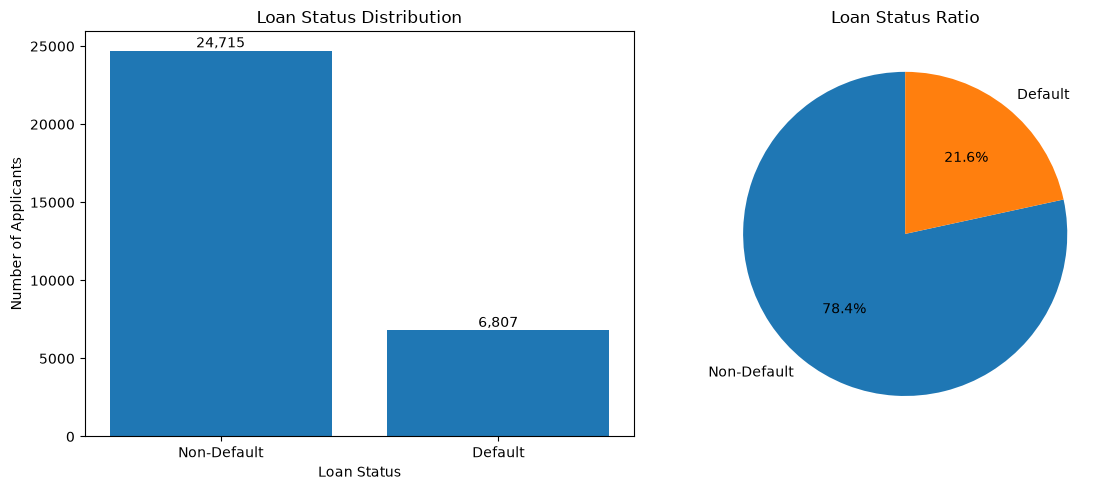

In [40]:
# Define labels
label_mapping = {
    0: "Non-Default",
    1: "Default"
}

labels = [label_mapping[i] for i in target_count.index]

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar Chart
axes[0].bar(labels, target_count.values)
axes[0].set_title("Loan Status Distribution")
axes[0].set_xlabel("Loan Status")
axes[0].set_ylabel("Number of Applicants")

for i, value in enumerate(target_count.values):
    axes[0].text(i, value, f"{value:,}", ha="center", va="bottom")

# Pie Chart
axes[1].pie(
    target_count.values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)
axes[1].set_title("Loan Status Ratio")

plt.tight_layout()
plt.show()

- The dataset contains **24,715** non-default loans and **6,807** default loans.
- The default rate is approximately **Z%**.
- Because the target classes are not perfectly balanced, evaluation metrics such as Precision, Recall, F1-score, and ROC-AUC should be considered in addition to Accuracy.

### Numerical Features

#### Univariate Analysis

In [41]:
numerical_features = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_grade",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length"
]

# Descriptive statistics
display(df_clean[numerical_features].describe().T)

,count,mean,std,min,25%,50%,75%,max
person_age,31522.0,27.742529,6.218713,20.0,23.00,26.00,30.00,94.00
person_income,31522.0,66501.683935,52752.156211,4000.0,39438.00,56000.00,80000.00,2039784.00
person_emp_length,31522.0,4.782850,4.037343,0.0,2.00,4.00,7.00,41.00
loan_grade,31522.0,5.771081,1.169064,1.0,5.00,6.00,7.00,7.00
loan_amnt,31522.0,9663.771334,6334.787700,500.0,5000.00,8000.00,12500.00,35000.00
loan_int_rate,31522.0,9.888539,4.693673,-1.0,7.49,10.65,13.16,23.22
loan_percent_income,31522.0,0.169658,0.106296,0.0,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,31522.0,5.816097,4.063622,2.0,3.00,4.00,8.00,30.00


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10780\2190925359.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(df_clean[feature], vert=True)


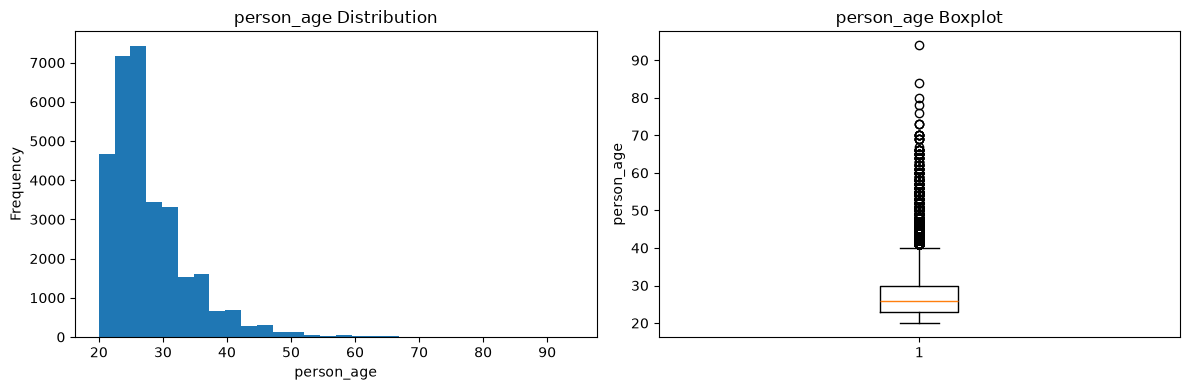

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10780\2190925359.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(df_clean[feature], vert=True)


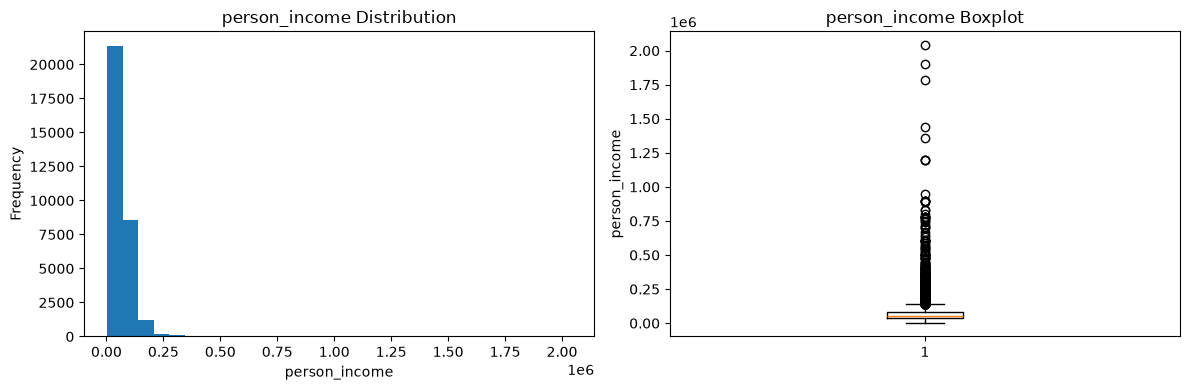

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10780\2190925359.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(df_clean[feature], vert=True)


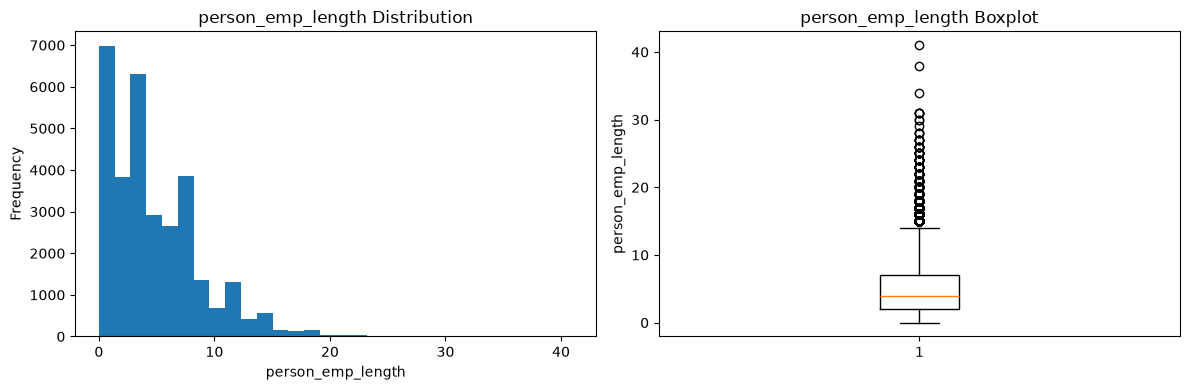

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10780\2190925359.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(df_clean[feature], vert=True)


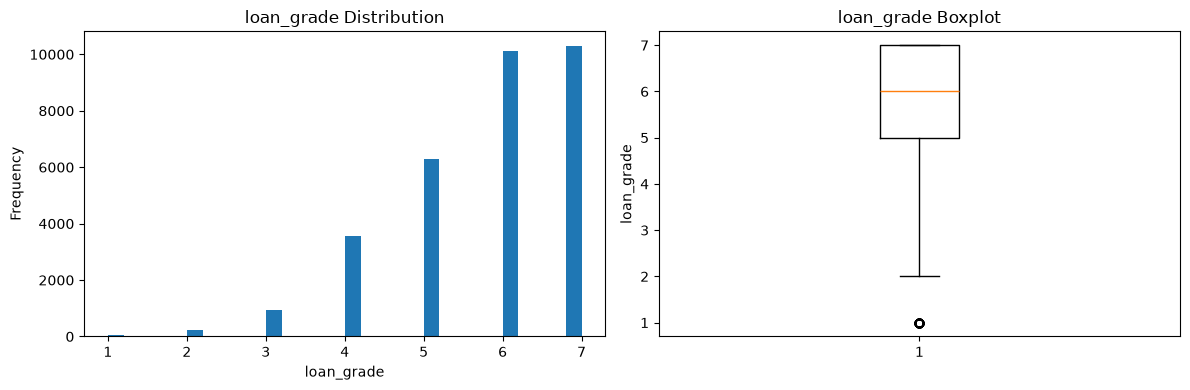

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10780\2190925359.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(df_clean[feature], vert=True)


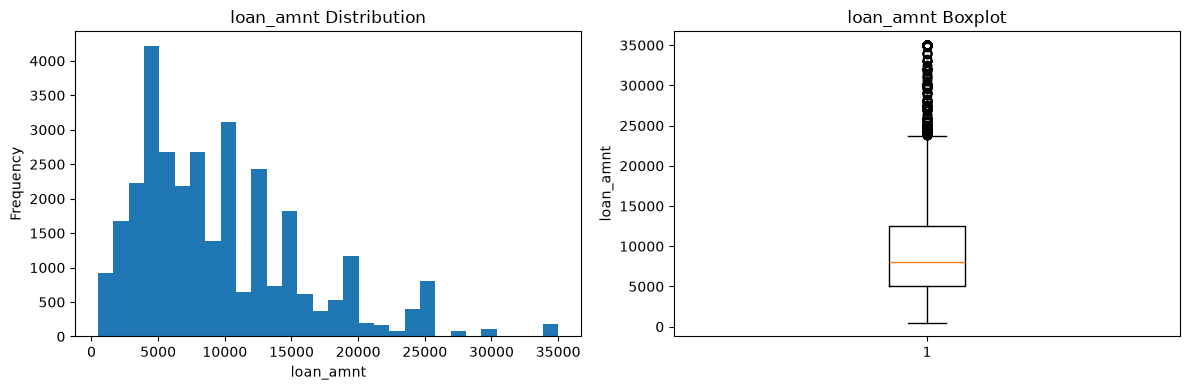

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10780\2190925359.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(df_clean[feature], vert=True)


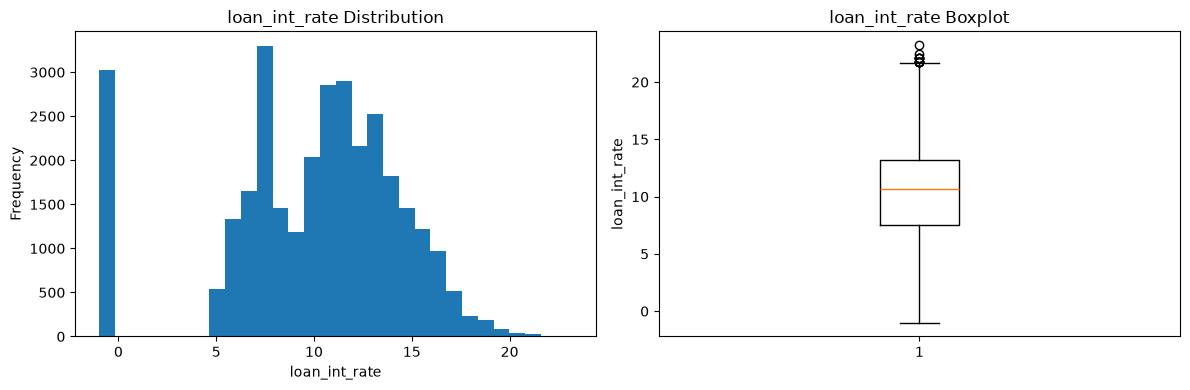

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10780\2190925359.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(df_clean[feature], vert=True)


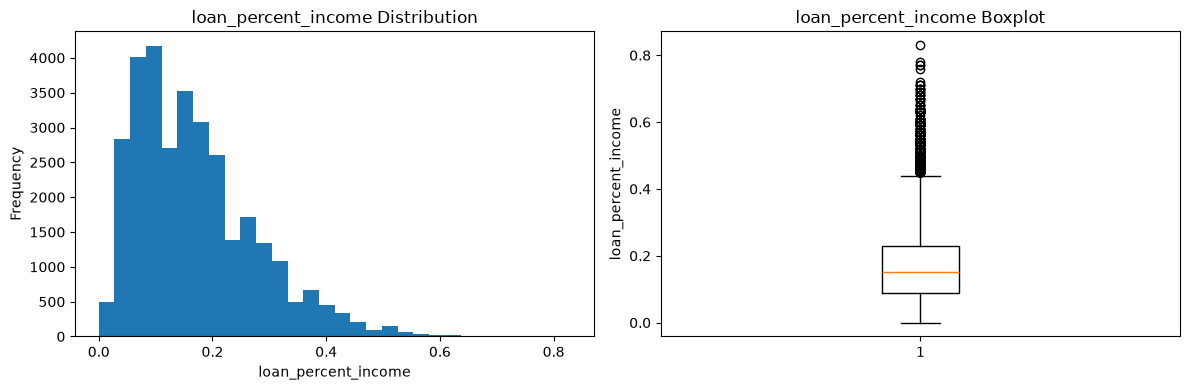

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10780\2190925359.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(df_clean[feature], vert=True)


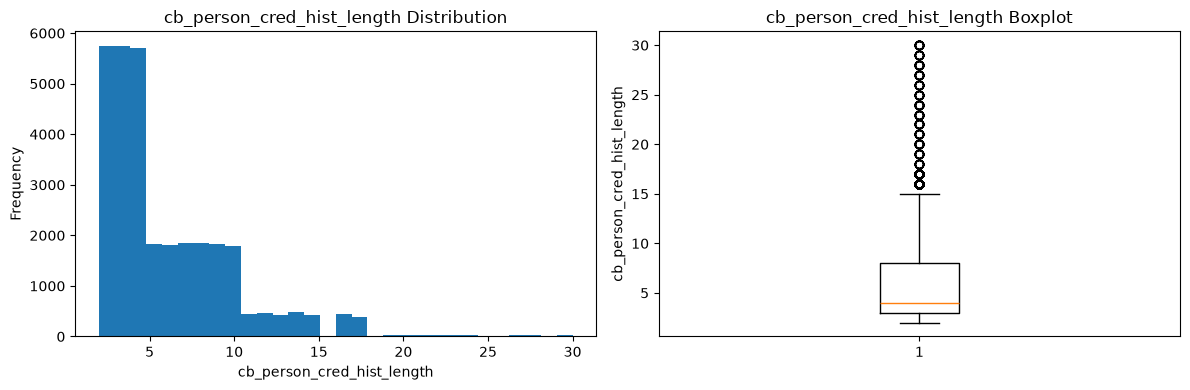

In [42]:
# Plot each numerical feature
for feature in numerical_features:

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram
    axes[0].hist(df_clean[feature], bins=30)
    axes[0].set_title(f"{feature} Distribution")
    axes[0].set_xlabel(feature)
    axes[0].set_ylabel("Frequency")

    # Boxplot
    axes[1].boxplot(df_clean[feature], vert=True)
    axes[1].set_title(f"{feature} Boxplot")
    axes[1].set_ylabel(feature)

    plt.tight_layout()
    plt.show()

- Overall, most numerical features exhibit **right-skewed distributions**, indicating that the majority of observations are concentrated at relatively low values, while a small proportion of applicants have substantially larger values.

- **Age:** Most loan applicants are between **20 and 30 years old**, with ages **25–26** representing the highest number of applications (nearly 7,000 observations). This suggests that young adults constitute the primary borrowing population in the dataset.

- **Annual Income:** Applicants with an annual income below **125,000 USD** account for the majority of loan applications, exceeding **20,000 observations**. The long right tail indicates that high-income borrowers exist but represent only a small portion of the dataset.

- **Employment Length:** More than **75%** of applicants have **less than 10 years of employment experience**, suggesting that individuals in the early stages of their careers are more likely to apply for loans.

- **Loan Grade:** Most loans are assigned **Grade A or Grade B**, indicating that borrowers with relatively strong credit quality dominate the dataset. Although lower credit grades are also present, they account for only a small proportion of observations.

- **Loan Amount:** More than **75%** of loan amounts are below **15,000 USD**, with **5,000 USD** being the most common borrowing amount. This indicates that the dataset is primarily composed of small- to medium-sized personal loans.

- **Interest Rate:** Approximately **75%** of loan interest rates are below **15%**, while higher interest rates become progressively less common. In addition, around **3,000 observations** contain an interest rate of **-1**, representing missing values introduced during data preprocessing. These observations should be interpreted as unavailable interest rate information rather than actual interest rates.

- **Loan Percent Income:** Most borrowers request loans equivalent to **less than 20% of their annual income**. The number of observations decreases rapidly as the loan-to-income ratio increases, indicating that large borrowing relative to income is relatively uncommon.

- **Credit History Length:** Approximately **50%** of applicants have **less than 5 years of credit history**, while more than **75%** have **less than 10 years**. This suggests that the dataset mainly consists of borrowers with relatively short credit histories.

**OVERALL INSIGHT**

The dataset is primarily composed of **young borrowers with low-to-middle annual income, relatively short employment experience, limited credit history, and good credit grades (Grade A–B)**. Most applicants request relatively small loan amounts that account for less than 20% of their annual income. Furthermore, nearly all numerical variables exhibit right-skewed distributions, indicating that only a small number of applicants possess exceptionally high income, loan amounts, employment length, or credit history.

#### Bivariate Analysis

,count,mean,std,min,25%,50%,75%,max
loan_status_label,,,,,,,,
Default,6807.0,27.47,6.26,20.0,23.0,26.0,30.0,70.0
Non-Default,24715.0,27.82,6.20,20.0,23.0,26.0,30.0,94.0


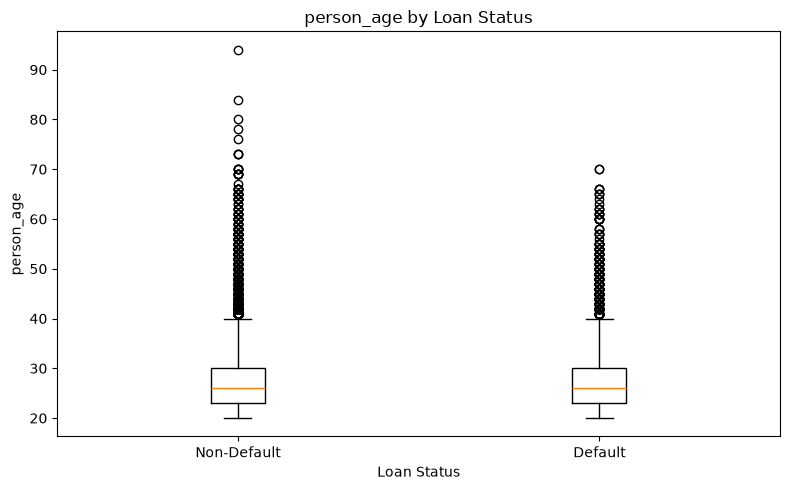

,count,mean,std,min,25%,50%,75%,max
loan_status_label,,,,,,,,
Default,6807.0,49930.38,36634.09,4000.0,30000.0,42000.0,60000.0,703800.0
Non-Default,24715.0,71065.75,55526.57,7000.0,42500.0,60000.0,85000.0,2039784.0


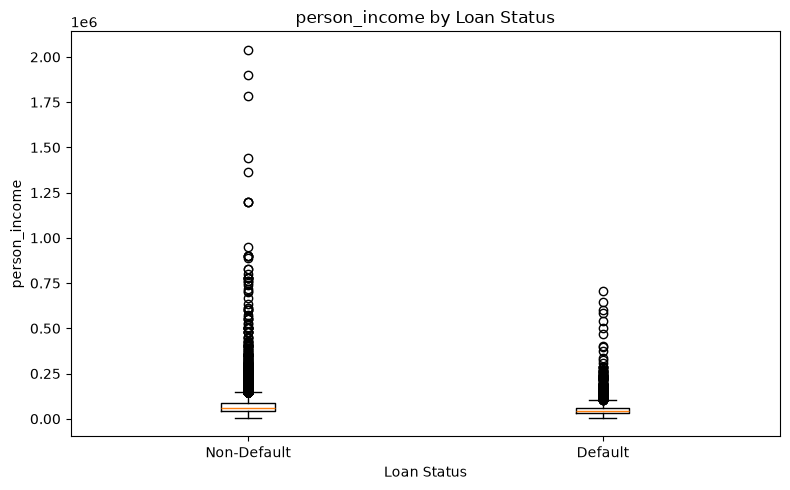

,count,mean,std,min,25%,50%,75%,max
loan_status_label,,,,,,,,
Default,6807.0,4.12,3.87,0.0,1.0,3.0,6.0,34.0
Non-Default,24715.0,4.97,4.06,0.0,2.0,4.0,7.0,41.0


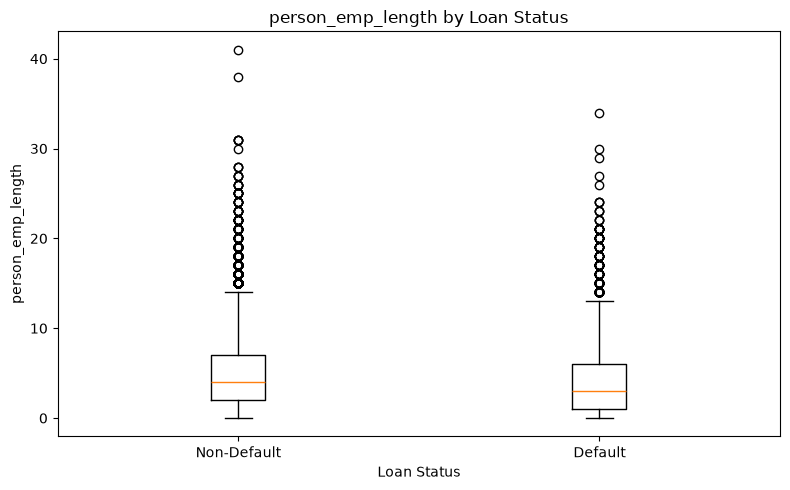

,count,mean,std,min,25%,50%,75%,max
loan_status_label,,,,,,,,
Default,6807.0,4.93,1.36,1.0,4.0,5.0,6.0,7.0
Non-Default,24715.0,6.00,0.99,1.0,5.0,6.0,7.0,7.0


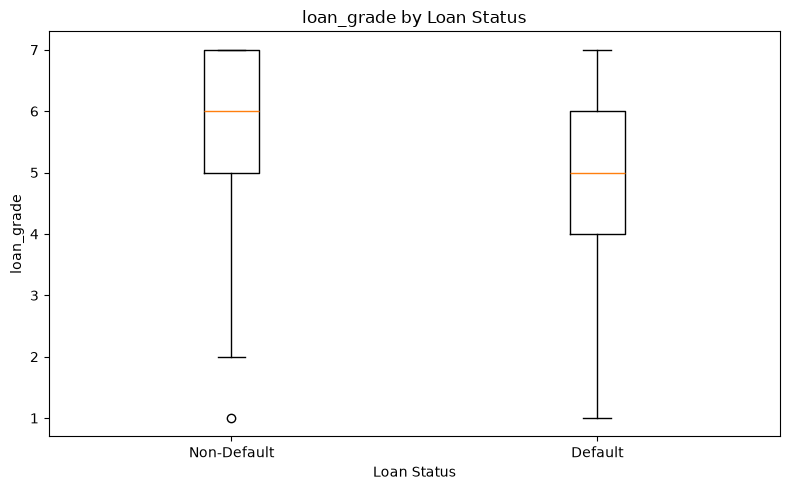

,count,mean,std,min,25%,50%,75%,max
loan_status_label,,,,,,,,
Default,6807.0,11022.90,7156.24,900.0,5000.0,10000.0,15000.0,35000.0
Non-Default,24715.0,9289.44,6035.75,500.0,5000.0,8000.0,12000.0,35000.0


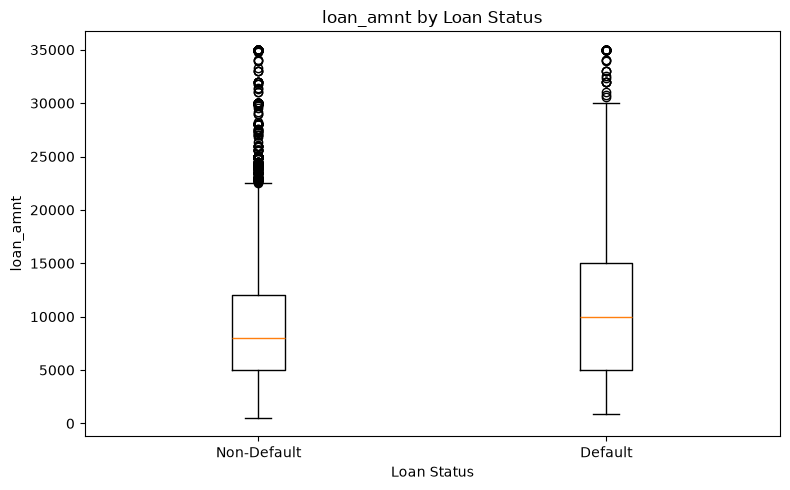

,count,mean,std,min,25%,50%,75%,max
loan_status_label,,,,,,,,
Default,6807.0,11.84,5.12,-1.0,9.99,13.11,15.31,23.22
Non-Default,24715.0,9.35,4.42,-1.0,7.29,10.00,12.53,22.06


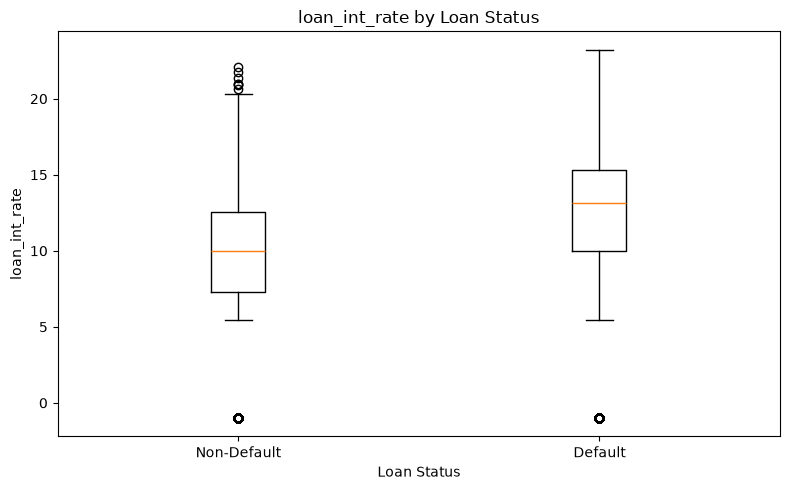

,count,mean,std,min,25%,50%,75%,max
loan_status_label,,,,,,,,
Default,6807.0,0.25,0.13,0.01,0.14,0.24,0.34,0.78
Non-Default,24715.0,0.15,0.09,0.00,0.08,0.13,0.20,0.83


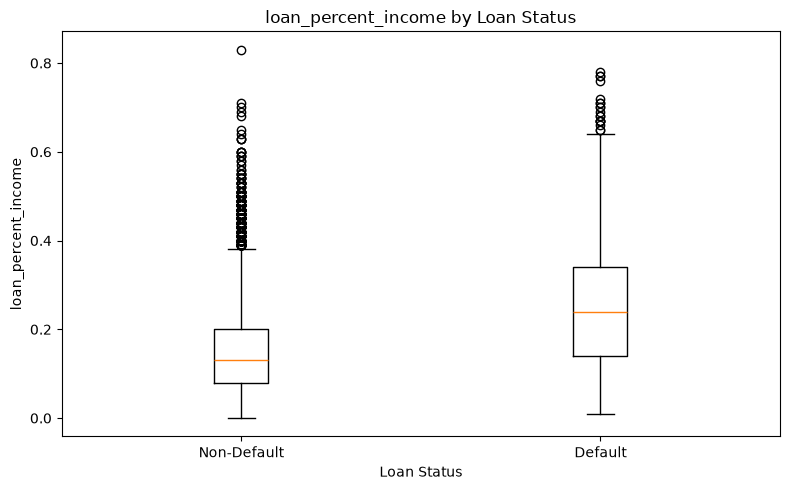

,count,mean,std,min,25%,50%,75%,max
loan_status_label,,,,,,,,
Default,6807.0,5.68,4.10,2.0,3.0,4.0,8.0,30.0
Non-Default,24715.0,5.85,4.05,2.0,3.0,4.0,8.0,30.0


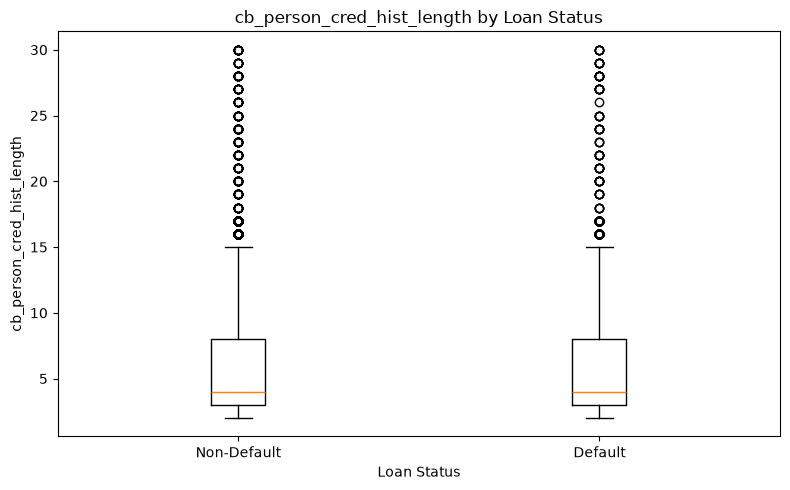

In [43]:
numerical_features = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_grade",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length"
]

target_mapping = {
    0: "Non-Default",
    1: "Default"
}

df_plot = df_clean.copy()
df_plot["loan_status_label"] = df_plot["loan_status"].map(target_mapping)

for feature in numerical_features:

    display(
        df_plot.groupby("loan_status_label")[feature]
        .describe()
        .round(2)
    )

    plt.figure(figsize=(8,5))

    data = [
        df_plot[df_plot["loan_status"] == 0][feature],
        df_plot[df_plot["loan_status"] == 1][feature]
    ]

    plt.boxplot(
        data,
        tick_labels=["Non-Default", "Default"]
    )

    plt.title(f"{feature} by Loan Status")
    plt.xlabel("Loan Status")
    plt.ylabel(feature)

    plt.tight_layout()
    plt.show()

- **Age:** There is little difference in age between default and non-default borrowers. Both groups have a median age of **26 years** and nearly identical distributions, suggesting that age alone is unlikely to be a strong predictor of loan default.

- **Annual Income:** Non-default borrowers have substantially higher annual incomes, with an average income of approximately **71,066 USD**, compared to **49,930 USD** for default borrowers. This indicates that higher income is associated with a lower probability of default.

- **Employment Length:** Borrowers who successfully repay their loans generally have longer employment histories. The average employment length is **4.97 years** for non-default borrowers versus **4.12 years** for default borrowers, suggesting that employment stability contributes to lower credit risk.

- **Loan Grade:** Loan grade shows one of the strongest separations between the two classes. Non-default borrowers have a mean credit grade of **6.00**, whereas default borrowers average only **4.93**, indicating that better credit grades are strongly associated with successful loan repayment.

- **Loan Amount:** Default borrowers receive larger loans on average (**11,023 USD**) than non-default borrowers (**9,289 USD**). This suggests that larger loan amounts may increase repayment risk.

- **Interest Rate:** Default borrowers typically receive loans with higher interest rates, averaging **11.84%** compared with **9.35%** for non-default borrowers. Higher interest rates are therefore associated with increased default risk.

- **Loan Percent Income:** This variable provides one of the clearest distinctions between the two classes. Default borrowers allocate approximately **25% of their annual income** to loan repayments, while non-default borrowers allocate only **15%** on average. A higher debt burden relative to income is therefore strongly associated with loan default.

- **Credit History Length:** The average credit history length is very similar between the two groups (**5.68** versus **5.85 years**), suggesting that this feature alone has limited discriminative power.

**OVERALL INSIGHT**

Among the numerical variables, **loan grade, annual income, loan amount, interest rate, and especially loan percent income** exhibit the strongest differences between default and non-default borrowers, making them promising predictors for credit risk modeling. In contrast, **age** and **credit history length** show considerable overlap between the two classes and are likely to contribute less predictive information when considered individually.

### Categorical Features

#### Univariate Analysis

,Count,Percentage (%)
person_home_ownership,,
RENT,16007,50.78
MORTGAGE,13018,41.30
OWN,2391,7.59
OTHER,106,0.34


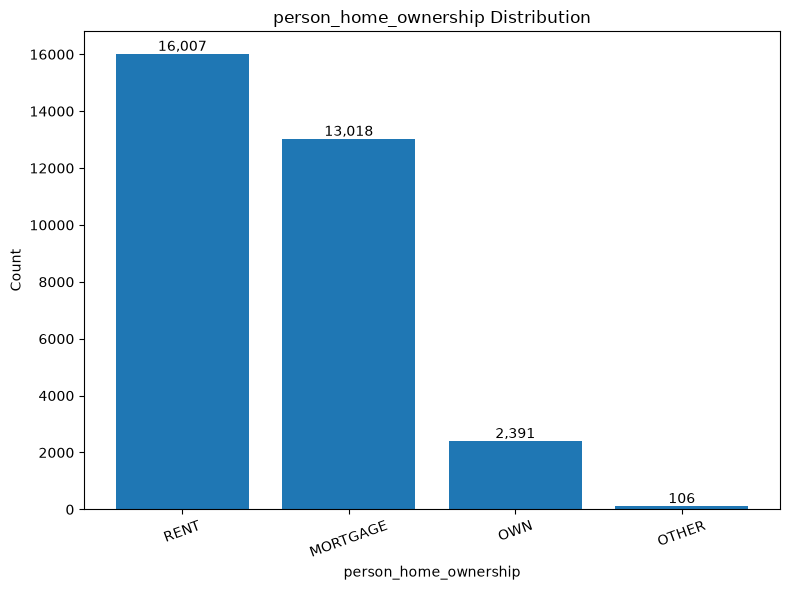

,Count,Percentage (%)
loan_intent,,
EDUCATION,6246,19.81
MEDICAL,5869,18.62
VENTURE,5518,17.51
PERSONAL,5346,16.96
DEBTCONSOLIDATION,5044,16.00
HOMEIMPROVEMENT,3499,11.10


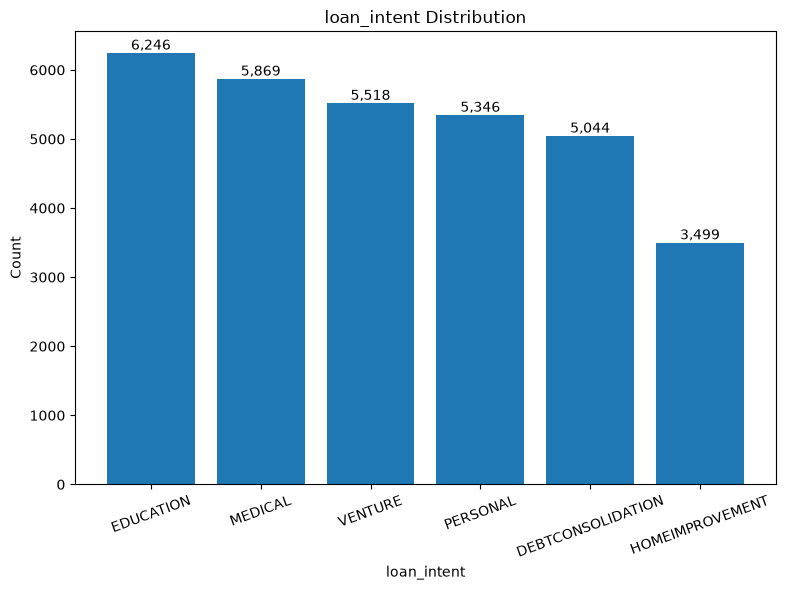

,Count,Percentage (%)
cb_person_default_on_file,,
N,25908,82.19
Y,5614,17.81


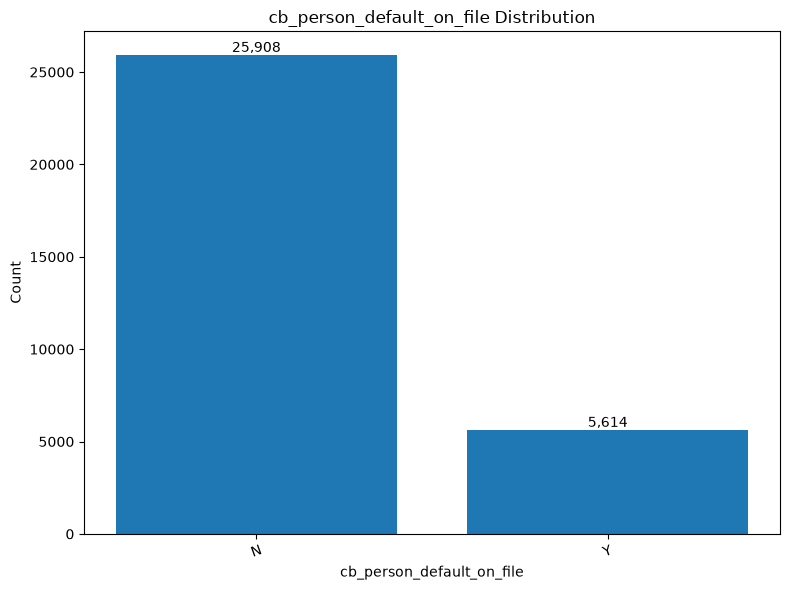

In [44]:
categorical_features = [
    "person_home_ownership",
    "loan_intent",
    "cb_person_default_on_file"
]

for feature in categorical_features:

    frequency = df_clean[feature].value_counts()
    percentage = (frequency / len(df_clean) * 100).round(2)

    summary = pd.DataFrame({
        "Count": frequency,
        "Percentage (%)": percentage
    })
    display(summary)

    plt.figure(figsize=(8,6))
    plt.bar(frequency.index.astype(str), frequency.values)

    plt.title(f"{feature} Distribution")
    plt.xlabel(feature)
    plt.ylabel("Count")

    for i, value in enumerate(frequency.values):
        plt.text(i, value, f"{value:,}", ha="center", va="bottom")

    plt.xticks(rotation=20)

    plt.tight_layout()
    plt.show()

- **Home Ownership:** The majority of borrowers either **rent their homes** or **have a mortgage**, with these two groups accounting for approximately **29,000 observations**. In comparison, around **2,300 applicants** own their homes outright, while only **106 observations** fall into the **"Other"** category. Although the exact meaning of the "Other" category requires further clarification from the dataset documentation, the overall distribution indicates that most borrowers do not fully own their homes at the time of applying for a loan.

- **Loan Intent:** Loan purposes are relatively evenly distributed across different categories, with only moderate differences in frequency. **Education** is the most common borrowing purpose, accounting for more than **6,200 applications**, followed by **medical expenses** (approximately **5,800**), **venture/business investment** (approximately **5,500**), **personal purposes** (approximately **5,300**), **debt consolidation** (approximately **5,000**), and **home improvement** (approximately **3,500**). This suggests that educational expenses represent the primary motivation for borrowing within the dataset.

- **Previous Default History:** Approximately **82.19%** of applicants have **no previous default history**, while the remaining **17.81%** have defaulted on a previous loan. This indicates that the dataset is dominated by borrowers with relatively good historical credit behavior.

**OVERALL INSIGHT**

The categorical variables suggest that the typical borrower is **someone who has not yet fully owned a home**, most commonly applies for a loan to **finance educational expenses**, and **does not have a previous history of loan default**. Overall, the dataset is largely composed of borrowers with relatively stable credit backgrounds seeking loans for common personal and educational financial needs.

#### Bivariate Analysis

loan_status_label,Default,Non-Default
person_home_ownership,,
MORTGAGE,12.50,87.50
OTHER,31.13,68.87
OWN,6.94,93.06
RENT,31.12,68.88


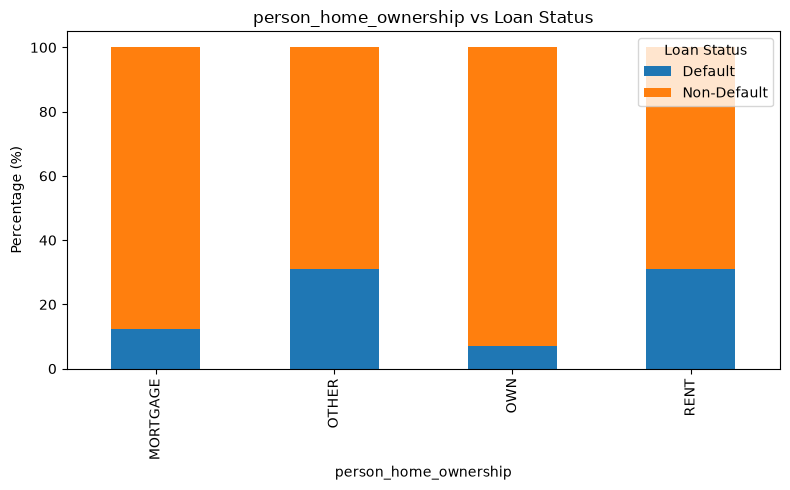

loan_status_label,Default,Non-Default
loan_intent,,
DEBTCONSOLIDATION,28.45,71.55
EDUCATION,16.99,83.01
HOMEIMPROVEMENT,25.61,74.39
MEDICAL,26.60,73.40
PERSONAL,19.51,80.49
VENTURE,14.70,85.30


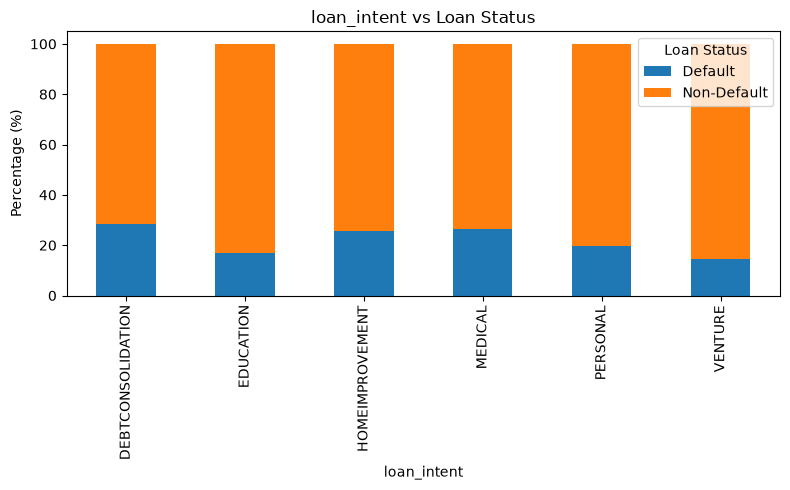

loan_status_label,Default,Non-Default
cb_person_default_on_file,,
N,18.12,81.88
Y,37.62,62.38


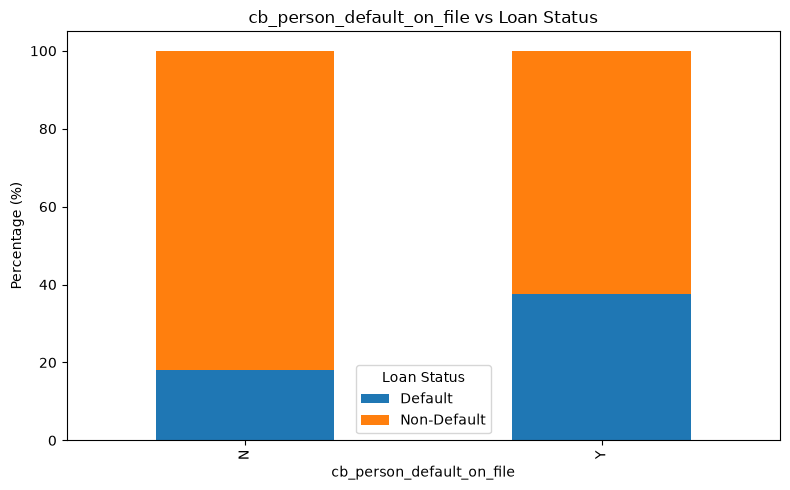

In [45]:
categorical_features = [
    "person_home_ownership",
    "loan_intent",
    "cb_person_default_on_file"
]

target_mapping = {
    0: "Non-Default",
    1: "Default"
}

df_plot = df_clean.copy()
df_plot["loan_status_label"] = df_plot["loan_status"].map(target_mapping)

for feature in categorical_features:

    # Percentage Table
    summary_percent = pd.crosstab(
        df_plot[feature],
        df_plot["loan_status_label"],
        normalize="index"
    ) * 100

    display(summary_percent.round(2))

    # Visualization
    summary_percent.plot(
        kind="bar",
        stacked=True,
        figsize=(8,5)
    )

    plt.title(f"{feature} vs Loan Status")
    plt.ylabel("Percentage (%)")
    plt.xlabel(feature)

    plt.legend(title="Loan Status")

    plt.tight_layout()
    plt.show()

- **Home Ownership:** Home ownership status exhibits a noticeable relationship with loan default. Borrowers who **own their homes outright** have the lowest default rate (**6.94%**), followed by those with a **mortgage** (**12.50%**). In contrast, applicants who **rent** their homes or belong to the **"Other"** category show substantially higher default rates of approximately **31%**. This suggests that stronger housing ownership is generally associated with greater financial stability and lower credit risk.

- **Loan Intent:** Default rates vary across different borrowing purposes. **Debt consolidation** loans have the highest default rate (**28.45%**), followed by **medical expenses** (**26.60%**) and **home improvement** (**25.61%**). Conversely, **venture/business investment** (**14.70%**) and **education** (**16.99%**) loans exhibit the lowest default rates. These results indicate that the purpose of borrowing may influence repayment behavior, although the differences are moderate compared with other features.

- **Previous Default History:** Previous default history demonstrates the strongest relationship with loan default among the categorical variables. Applicants with **no previous default history ("N")** have a default rate of only **18.12%**, whereas those with a **previous default record ("Y")** have a substantially higher default rate of **37.62%**. This suggests that borrowers who have defaulted in the past are more than twice as likely to default again, making previous default history one of the most informative predictors of credit risk.

**OVERALL INSIGHT**

Among the categorical variables, **previous default history** provides the strongest discriminatory power for predicting loan default, followed by **home ownership status**. While **loan purpose** also influences repayment outcomes, its impact is comparatively weaker. Overall, borrowers with a stable financial background—such as those who own their homes and have no prior default history—are considerably less likely to default than renters or borrowers with previous credit issues.

### Correlation Analysis

,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
person_age,1.00,0.14,0.17,-0.01,0.05,-0.00,-0.02,-0.04,0.88
person_income,0.14,1.00,0.15,0.01,0.31,-0.01,-0.16,-0.29,0.12
person_emp_length,0.17,0.15,1.00,0.05,0.11,-0.04,-0.09,-0.06,0.15
loan_grade,-0.01,0.01,0.05,1.00,-0.14,-0.58,-0.38,-0.13,-0.01
loan_amnt,0.05,0.31,0.11,-0.14,1.00,0.09,0.11,0.58,0.04
loan_int_rate,-0.00,-0.01,-0.04,-0.58,0.09,1.00,0.22,0.07,-0.00
loan_status,-0.02,-0.16,-0.09,-0.38,0.11,0.22,1.00,0.38,-0.02
loan_percent_income,-0.04,-0.29,-0.06,-0.13,0.58,0.07,0.38,1.00,-0.03
cb_person_cred_hist_length,0.88,0.12,0.15,-0.01,0.04,-0.00,-0.02,-0.03,1.00


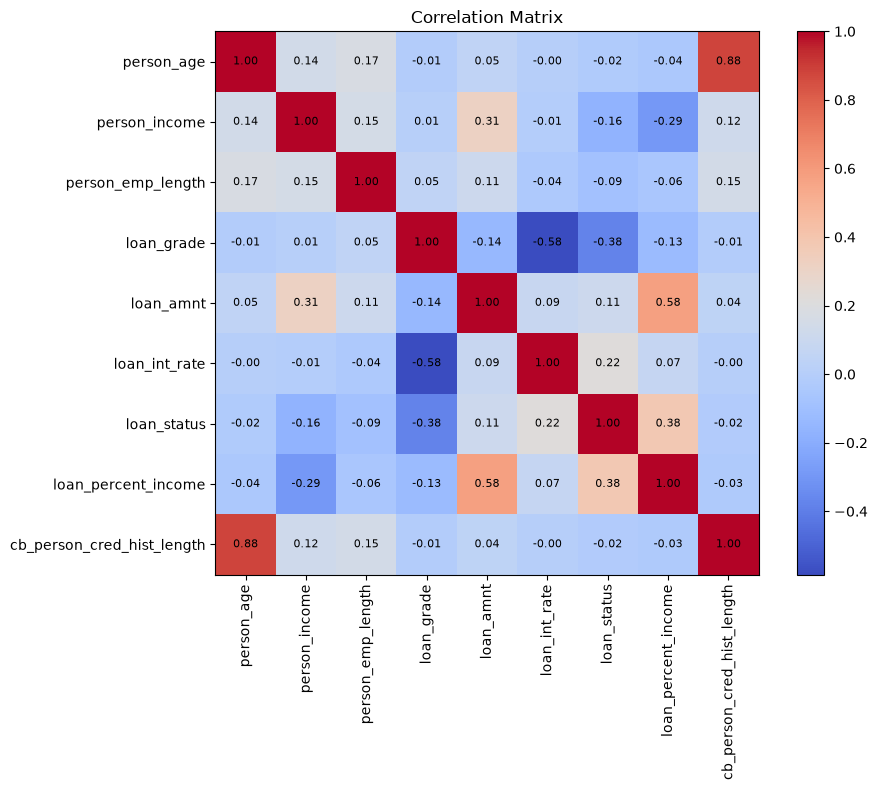

In [46]:
correlation_matrix = df_clean.corr(numeric_only=True)

display(correlation_matrix.round(2))

plt.figure(figsize=(10,8))

plt.imshow(correlation_matrix, cmap="coolwarm", interpolation="nearest")
plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

# Annotate correlation values
for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

In [47]:
# Correlation with target
target_corr = (
    correlation_matrix["loan_status"]
    .drop("loan_status")
    .sort_values(key=abs, ascending=False)
)

print("\nCorrelation with Loan Status")
display(target_corr.to_frame("Correlation"))


Correlation with Loan Status


,Correlation
loan_percent_income,0.380069
loan_grade,-0.377279
loan_int_rate,0.218606
person_income,-0.164862
loan_amnt,0.112598
person_emp_length,-0.086313
person_age,-0.023164
cb_person_cred_hist_length,-0.017781


- **Correlation with the Target Variable:** The correlation matrix indicates that **`loan_grade`** and **`loan_percent_income`** have the strongest relationships with the target variable (`loan_status`), with correlation coefficients of **-0.38** and **0.38**, respectively. The negative correlation of `loan_grade` suggests that higher credit grades (e.g., Grade A) are associated with a lower probability of default, while the positive correlation of `loan_percent_income` indicates that borrowers allocating a larger proportion of their income to loan repayment are more likely to default.

- **Other Relationships with the Target:** **`loan_int_rate`** also exhibits a moderate positive correlation with `loan_status` (**0.22**), implying that loans with higher interest rates are generally associated with higher default risk. In contrast, **`person_income`** shows a weak negative correlation (**-0.16**), suggesting that borrowers with higher annual incomes tend to have lower default rates. Variables such as **`loan_amnt`** (**0.11**) and **`person_emp_length`** (**-0.09**) have relatively weak relationships with the target, while **`person_age`** and **`cb_person_cred_hist_length`** show almost no linear correlation with loan default.

- **Correlation Among Features:** Most feature pairs exhibit weak to moderate correlations, indicating that they provide relatively independent information. However, **`person_age`** and **`cb_person_cred_hist_length`** have a very strong positive correlation (**0.88**), which is expected because older borrowers typically possess longer credit histories. Additionally, **`loan_grade`** and **`loan_int_rate`** have a moderately strong negative correlation (**-0.58**), suggesting that borrowers with better credit grades generally receive lower interest rates. Similarly, **`loan_amnt`** and **`loan_percent_income`** show a moderately strong positive correlation (**0.58**), indicating that larger loan amounts tend to account for a greater proportion of borrowers' annual incomes.

**OVERALL INSIGHT**

Overall, the dataset exhibits **limited multicollinearity**, as most feature pairs have relatively low correlation coefficients. The only notable exception is the strong relationship between **`person_age`** and **`cb_person_cred_hist_length`**, which may introduce multicollinearity in linear models. Regarding credit risk prediction, **`loan_grade`**, **`loan_percent_income`**, **`loan_int_rate`**, and **`person_income`** demonstrate the strongest linear relationships with loan default. These findings are consistent with the previous bivariate analysis, further confirming that borrowers' credit quality, debt burden, interest rate, and income level are among the most influential factors associated with default risk.

### Feature Relationship Analysis

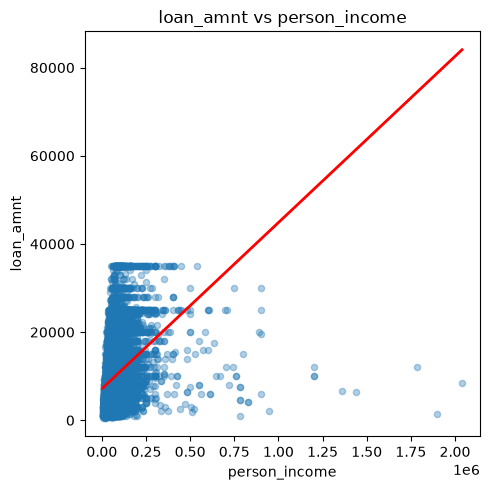

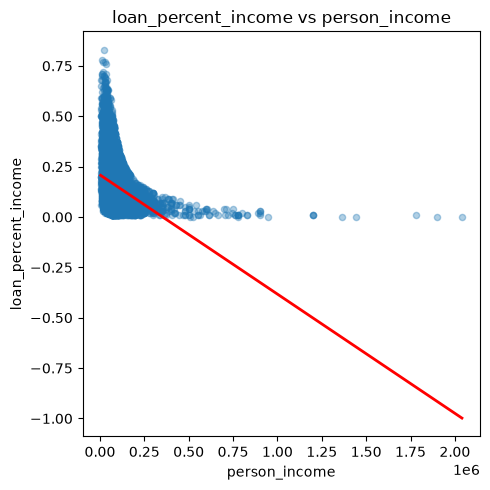

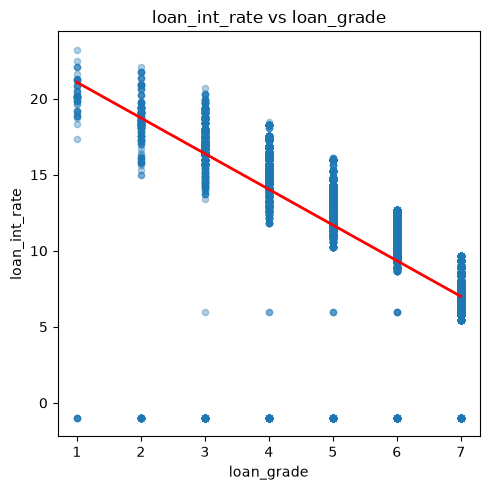

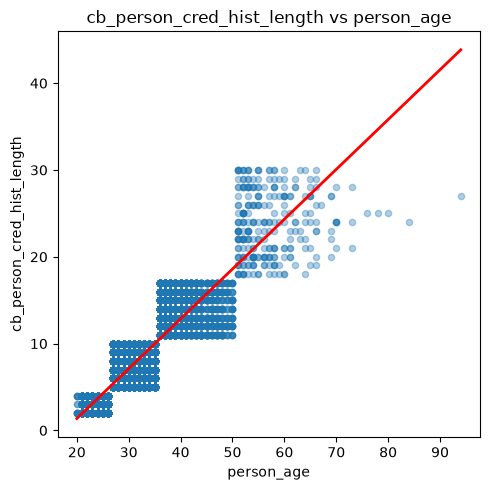

In [49]:
feature_pairs = [
    ("person_income", "loan_amnt"),
    ("person_income", "loan_percent_income"),
    ("loan_grade", "loan_int_rate"),
    ("person_age", "cb_person_cred_hist_length")
]

for x, y in feature_pairs:

    plt.figure(figsize=(5,5))

    sns.regplot(
        data=df_clean,
        x=x,
        y=y,
        scatter_kws={"alpha":0.35, "s":20},
        line_kws={"color":"red", "linewidth":2},
        ci=None
    )

    plt.title(f"{y} vs {x}")
    plt.tight_layout()
    plt.show()

- **Annual Income vs Loan Amount:** A generally positive relationship can be observed between **`person_income`** and **`loan_amnt`**, indicating that borrowers with higher annual incomes tend to receive larger loans. However, the relationship is not strictly linear. Several high-income borrowers (earning over one million dollars annually) only applied for relatively small loans of around $10,000, while most of the largest loan amounts were concentrated among borrowers with annual incomes below $250,000. This suggests that loan size is influenced by multiple factors beyond income alone.

- **Annual Income vs Loan-to-Income Ratio:** The relationship between **`person_income`** and **`loan_percent_income`** exhibits a clear decreasing trend, resembling an exponential decay. As borrowers' annual incomes increase, the proportion of income allocated to loan repayments declines substantially. Conversely, borrowers earning less than approximately $250,000 account for the highest loan-to-income ratios, indicating a relatively heavier debt burden compared to higher-income individuals.

- **Loan Grade vs Interest Rate:** A strong inverse relationship is evident between **`loan_grade`** and **`loan_int_rate`**. Borrowers with higher loan grades consistently receive lower interest rates, reflecting the risk-based pricing strategy commonly adopted by financial institutions. This finding is consistent with the negative correlation observed in the previous correlation analysis.

- **Age vs Employment Length:** A clear positive relationship exists between **`person_age`** and **`person_emp_length`**, suggesting that older borrowers generally have longer employment histories. The scatter plot also shows relatively few noticeable outliers, indicating that the relationship is stable and consistent across most observations.

**OVERALL INSIGHT**

The feature relationship analysis reveals several meaningful patterns among the explanatory variables. Income is positively associated with loan amount while negatively associated with the loan-to-income ratio, suggesting that higher-income borrowers generally borrow more in absolute terms but assume a smaller financial burden relative to their earnings. In addition, loan grade strongly influences interest rates, and employment length naturally increases with age. These relationships further validate the patterns identified in the previous bivariate and correlation analyses and provide additional business context for understanding borrower characteristics and credit risk.